# House prices — gradient boosting + learning curve

One small experiment a day. Seed fixed for reproducibility.

Does GBM beat ridge here, and does more data still help?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1230

rng = np.random.RandomState(SEED)
n = 3000
sqft = rng.uniform(500, 4000, n).round(0)
bedrooms = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.10, 0.30, 0.35, 0.20, 0.05])
bathrooms = np.clip(bedrooms - rng.choice([0, 1], size=n, p=[0.6, 0.4]), 1, 5)
age_yrs = rng.uniform(0, 60, n).round(1)
neighborhood = rng.choice(["A", "B", "C", "D"], size=n, p=[0.25, 0.35, 0.25, 0.15])
hood_eff = {"A": 42000, "B": 16000, "C": 0, "D": -22000}
price = (80000 + 118 * sqft + 14500 * bedrooms - 850 * age_yrs
         + np.array([hood_eff[x] for x in neighborhood])
         + rng.normal(0, 28000, n))
df = pd.DataFrame({"Sqft": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms,
                   "Age": age_yrs, "Neighborhood": neighborhood,
                   "Price": price.round(0).astype(int)})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nmedian price: %d" % int(df["Price"].median()))


shape: (3000, 6)
     Sqft  Bedrooms  Bathrooms   Age Neighborhood   Price
0  1470.0         3          3  17.3            A  313144
1  1790.0         3          3   7.1            B  335197
2  2755.0         1          1   4.9            D  376076

median price: 369320


## Model + learning curve

gbm  r2: 0.9498 | rmse: 28,432
cv rmse at full size: 29,046


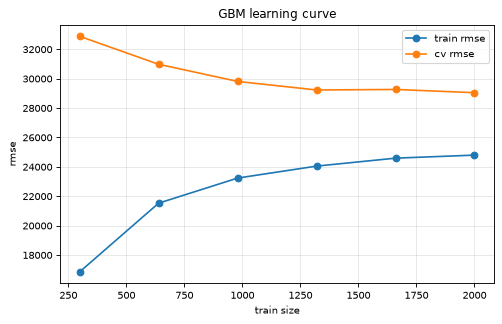

In [ ]:
num_features = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
cat_features = ['Neighborhood']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Price"]); y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
gbm = Pipeline([("prep", preprocess),
                ("model", GradientBoostingRegressor(random_state=SEED))])
gbm.fit(X_train, y_train)
pred = gbm.predict(X_test)
print(f"gbm  r2: {r2_score(y_test, pred):.4f} | rmse: {np.sqrt(mean_squared_error(y_test, pred)):,.0f}")
sizes, tr, va = learning_curve(gbm, X, y, cv=3, train_sizes=np.linspace(0.15, 1.0, 6),
                               scoring="neg_mean_squared_error", n_jobs=1)
tr_rmse = np.sqrt(-tr.mean(1)); va_rmse = np.sqrt(-va.mean(1))
fig, ax = plt.subplots()
ax.plot(sizes, tr_rmse, marker="o", label="train rmse")
ax.plot(sizes, va_rmse, marker="o", label="cv rmse")
ax.set_xlabel("train size"); ax.set_ylabel("rmse")
ax.legend(); ax.set_title("GBM learning curve")
print(f"cv rmse at full size: {va_rmse[-1]:,.0f}")


## What I learned

- GBM is roughly on par with ridge here; the neighborhood effect has a mild non-linearity.
- Learning curve is still sloping down: more data would help a bit.